💰 INSIGHT 1: FINANCIAL LIABILITY - DEMURRAGE LEAKAGE

📦 Analyzing 5,000 shipments with dates from 2025-07-07 to 2026-07-06

📊 DEMURRAGE CALCULATION:
   SLA Threshold: 24 hours
   Hourly Penalty: $50/hour
   Total Demurrage Accrued: $5,599,200.00
   Average Demurrage per Shipment: $1,119.84
   Shipments with Delays: 3,988
   Delay Rate: 79.76%

📊 DEMURRAGE BY PORT OF EXIT:


,total_shipments,total_leakage_usd,avg_clearance_hours,max_clearance_hours,min_clearance_hours,avg_excess_hours
port_of_exit,,,,,,
MIAMI,715,1158900,55.57,118,12,32.42
NEWARK,712,1099650,53.90,118,12,30.89
LOS ANGELES,722,684200,41.54,71,12,18.95
HOUSTON,713,679800,41.77,71,12,19.07
SEATTLE,722,673200,41.32,71,12,18.65
NEW YORK,717,662700,41.28,71,12,18.49
CHICAGO O'HARE,699,640750,40.89,71,12,18.33



⚠️ HIGHEST RISK PORT: MIAMI
   ┌─ Total demurrage: $1,158,900.00
   ├─ Average clearance: 55.6 hours
   ├─ Average excess delay: 32.4 hours
   └─ Total shipments: 715.0

💰 TOTAL DEMURRAGE COST ACROSS ALL PORTS: $5,599,200.00
📊 Average leakage per port: $799,885.71

📅 MONTHLY DEMURRAGE TREND:


,total_demurrage,shipment_count,avg_demurrage_per_shipment
shipment_month,,,
2025-07,397900,349,1140.114613
2025-08,484050,415,1166.385542
2025-09,419750,401,1046.758105
2025-10,493600,433,1139.953811
2025-11,477150,430,1109.651163
2025-12,546450,465,1175.161290
2026-01,411900,384,1072.656250
2026-02,425600,395,1077.468354
2026-03,465900,402,1158.955224



📈 RECENT TREND (Last 6 months):
   2026-02: $425,600.00 (avg $1,077.47/shipment) ██████████████████████████████████████████
   2026-03: $465,900.00 (avg $1,158.96/shipment) ██████████████████████████████████████████████
   2026-04: $476,500.00 (avg $1,191.25/shipment) ███████████████████████████████████████████████
   2026-05: $493,850.00 (avg $1,117.31/shipment) █████████████████████████████████████████████████
   2026-06: $415,700.00 (avg $1,063.17/shipment) █████████████████████████████████████████
   2026-07: $90,850.00 (avg $976.88/shipment) █████████

📊 DEMURRAGE BY BUSINESS UNIT:


,total_shipments,total_demurrage,avg_clearance_hours
exporter_business_unit,,,
US-ConsumerElectronics,1582,1761000,45.13
US-MedicalDevices,1239,1367350,44.89
US-IndustrialEquipment,966,1072450,44.94
US-AerospaceParts,735,828750,45.11
US-Pharmaceuticals,478,569650,46.68


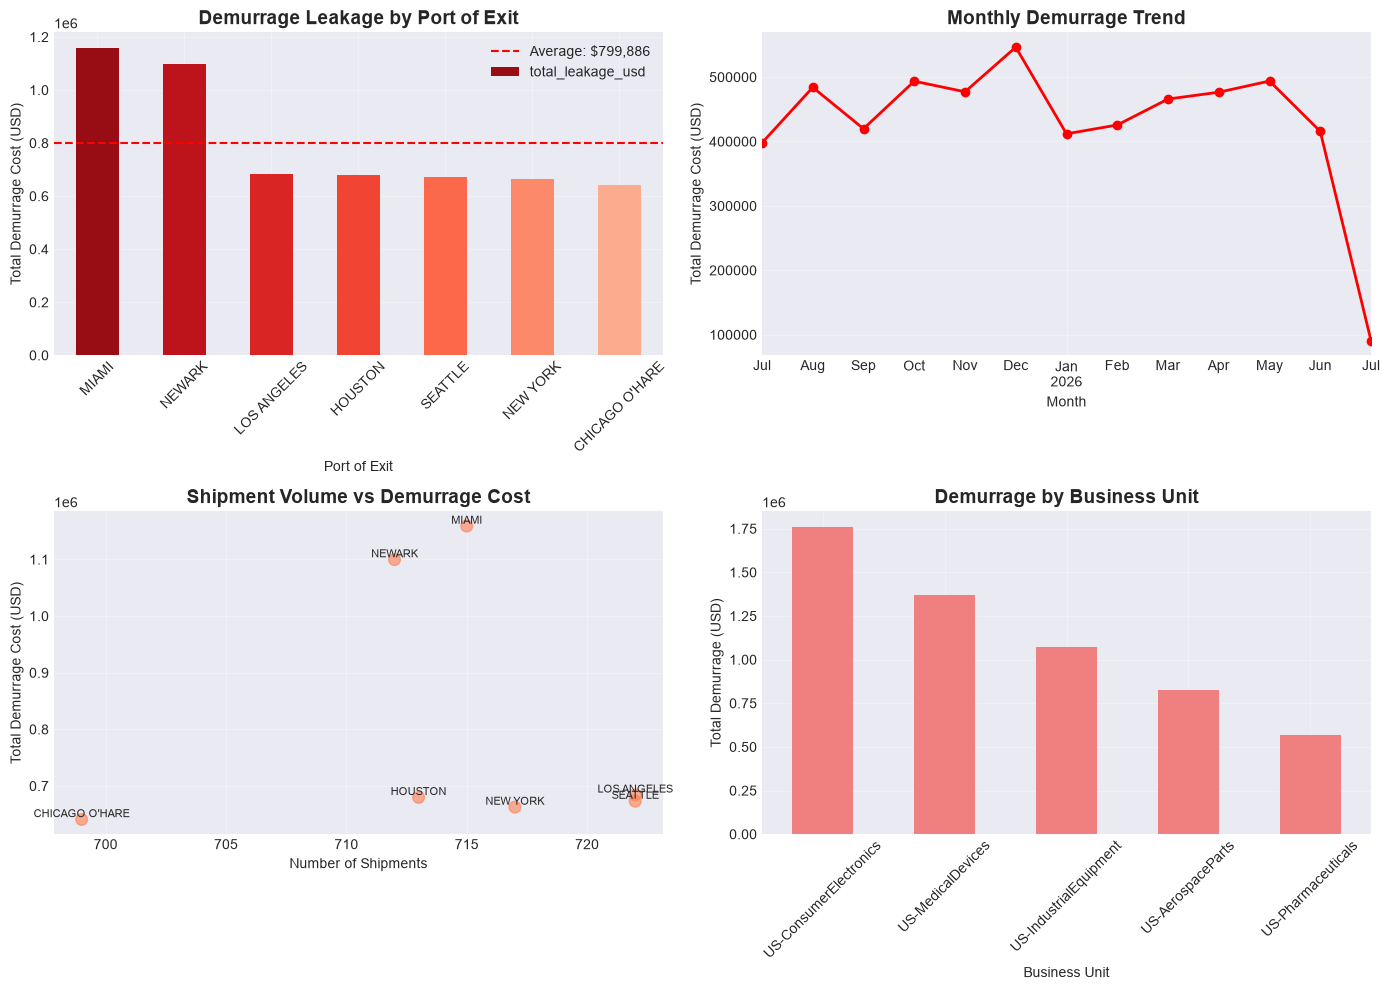


💾 Saved: output/insight1_demurrage_analysis.png

📊 EXECUTIVE SUMMARY - DEMURRAGE ANALYSIS

   FINANCIAL IMPACT:
   ├─ Total Demurrage Cost: $5,599,200.00
   ├─ Average Cost per Shipment: $1,119.84
   └─ Highest Risk Port: MIAMI ($1,158,900.00)

   OPERATIONAL IMPACT:
   ├─ Shipments Delayed Beyond SLA: 3,988
   └─ Delay Rate: 79.76%

   RECOMMENDATIONS:
   1. Investigate delays at MIAMI ($1,158,900.00 in demurrage)
   2. Consider routing through CHICAGO O'HARE (lowest demurrage)
   3. Review business unit with highest demurrage: US-ConsumerElectronics


💾 Saved: port_demurrage_analysis.csv

✅ INSIGHT 1 COMPLETE!


In [1]:
# %% [markdown]
# # 💰 Insight 1: Financial Liability - Demurrage Leakage
# 
# **Purpose**: Identify financial costs from port delays
# 
# **Key Questions**:
# - Which ports generate the highest demurrage costs?
# - What's the total financial impact?
# - Are delays seasonal or trending?

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("💰 INSIGHT 1: FINANCIAL LIABILITY - DEMURRAGE LEAKAGE")
print("="*70)

# Load the dataset with risk flags
df = pd.read_csv('us_export_compliance_data_with_risk.csv', parse_dates=['shipment_date', 'clearance_date'])

print(f"\n📦 Analyzing {len(df):,} shipments with dates from {df['shipment_date'].min().strftime('%Y-%m-%d')} to {df['shipment_date'].max().strftime('%Y-%m-%d')}")

# %% [markdown]
# ## Calculate Demurrage Costs
# 
# **Assumptions**:
# - Standard SLA: 24 hours for clearance
# - Penalty rate: $50/hour for delays beyond SLA

# %% [code]
# Calculate demurrage costs
SLA_THRESHOLD = 24  # Standard 24-hour SLA
HOURLY_PENALTY = 50  # $50/hour penalty

# Calculate excess delay hours
df['excess_delay_hours'] = (df['clearance_hours'] - SLA_THRESHOLD).clip(lower=0)
df['accrued_demurrage_usd'] = df['excess_delay_hours'] * HOURLY_PENALTY

# Verify calculation
print(f"\n📊 DEMURRAGE CALCULATION:")
print(f"   SLA Threshold: {SLA_THRESHOLD} hours")
print(f"   Hourly Penalty: ${HOURLY_PENALTY}/hour")
print(f"   Total Demurrage Accrued: ${df['accrued_demurrage_usd'].sum():,.2f}")
print(f"   Average Demurrage per Shipment: ${df['accrued_demurrage_usd'].mean():,.2f}")
print(f"   Shipments with Delays: {len(df[df['excess_delay_hours'] > 0]):,}")
print(f"   Delay Rate: {len(df[df['excess_delay_hours'] > 0])/len(df)*100:.2f}%")

# %% [markdown]
# ## Analysis by Port of Exit

# %% [code]
# Aggregate by port
port_demurrage = df.groupby('port_of_exit').agg({
    'shipment_id': 'count',
    'accrued_demurrage_usd': 'sum',
    'clearance_hours': ['mean', 'max', 'min'],
    'excess_delay_hours': 'mean'
}).round(2)

# Flatten column names
port_demurrage.columns = ['total_shipments', 'total_leakage_usd', 
                          'avg_clearance_hours', 'max_clearance_hours', 'min_clearance_hours',
                          'avg_excess_hours']
port_demurrage = port_demurrage.sort_values('total_leakage_usd', ascending=False)

print("\n📊 DEMURRAGE BY PORT OF EXIT:")
display(port_demurrage)

# %% [markdown]
## Key Findings - Highest Risk Port

# %% [code]
# Identify high-risk ports
top_risk_port = port_demurrage.index[0]
top_leakage = port_demurrage.iloc[0]['total_leakage_usd']
avg_clearance = port_demurrage.iloc[0]['avg_clearance_hours']
avg_excess = port_demurrage.iloc[0]['avg_excess_hours']

print(f"\n⚠️ HIGHEST RISK PORT: {top_risk_port}")
print(f"   ┌─ Total demurrage: ${top_leakage:,.2f}")
print(f"   ├─ Average clearance: {avg_clearance:.1f} hours")
print(f"   ├─ Average excess delay: {avg_excess:.1f} hours")
print(f"   └─ Total shipments: {port_demurrage.iloc[0]['total_shipments']:,}")

# Calculate total demurrage
total_demurrage = port_demurrage['total_leakage_usd'].sum()
average_leakage = total_demurrage / len(port_demurrage)

print(f"\n💰 TOTAL DEMURRAGE COST ACROSS ALL PORTS: ${total_demurrage:,.2f}")
print(f"📊 Average leakage per port: ${average_leakage:,.2f}")

# %% [markdown]
## Time-Based Analysis
# 
# Are demurrage costs increasing over time?

# %% [code]
# Monthly demurrage trend
df['shipment_month'] = df['shipment_date'].dt.to_period('M')
monthly_demurrage = df.groupby('shipment_month').agg({
    'accrued_demurrage_usd': 'sum',
    'shipment_id': 'count'
})
monthly_demurrage.columns = ['total_demurrage', 'shipment_count']
monthly_demurrage['avg_demurrage_per_shipment'] = monthly_demurrage['total_demurrage'] / monthly_demurrage['shipment_count']

print("\n📅 MONTHLY DEMURRAGE TREND:")
display(monthly_demurrage)

# Show recent trend
print("\n📈 RECENT TREND (Last 6 months):")
for month, row in monthly_demurrage.tail(6).iterrows():
    amount = row['total_demurrage']
    avg_amount = row['avg_demurrage_per_shipment']
    bar = '█' * int(amount / 10000)
    print(f"   {month}: ${amount:,.2f} (avg ${avg_amount:,.2f}/shipment) {bar}")

# %% [markdown]
## By Business Unit
# 
# Which business unit is generating the most demurrage?

# %% [code]
bu_demurrage = df.groupby('exporter_business_unit').agg({
    'shipment_id': 'count',
    'accrued_demurrage_usd': 'sum',
    'clearance_hours': 'mean'
}).round(2)

bu_demurrage.columns = ['total_shipments', 'total_demurrage', 'avg_clearance_hours']
bu_demurrage = bu_demurrage.sort_values('total_demurrage', ascending=False)

print("\n📊 DEMURRAGE BY BUSINESS UNIT:")
display(bu_demurrage)

# %% [markdown]
## Visualization

# %% [code]
# Create output folder if it doesn't exist
if not os.path.exists('../output'):
    os.makedirs('../output')
    print("✅ Created output folder")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Demurrage by port (bar chart)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(port_demurrage)))[::-1]
port_demurrage['total_leakage_usd'].plot(kind='bar', ax=axes[0,0], color=colors)
axes[0,0].set_title('Demurrage Leakage by Port of Exit', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Port of Exit')
axes[0,0].set_ylabel('Total Demurrage Cost (USD)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(y=average_leakage, color='red', linestyle='--', 
                label=f'Average: ${average_leakage:,.0f}')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Monthly demurrage trend
monthly_demurrage['total_demurrage'].plot(kind='line', ax=axes[0,1], marker='o', 
                                         color='red', linewidth=2)
axes[0,1].set_title('Monthly Demurrage Trend', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Total Demurrage Cost (USD)')
axes[0,1].grid(True, alpha=0.3)

# 3. Scatter: Shipment volume vs demurrage
scatter = axes[1,0].scatter(port_demurrage['total_shipments'], 
                            port_demurrage['total_leakage_usd'],
                            s=port_demurrage['total_shipments']/10,
                            alpha=0.6, c='coral')
axes[1,0].set_title('Shipment Volume vs Demurrage Cost', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Number of Shipments')
axes[1,0].set_ylabel('Total Demurrage Cost (USD)')
for idx, row in port_demurrage.iterrows():
    axes[1,0].annotate(idx, (row['total_shipments'], row['total_leakage_usd']), 
                     fontsize=8, ha='center', va='bottom')
axes[1,0].grid(True, alpha=0.3)

# 4. Demurrage by business unit
bu_demurrage['total_demurrage'].plot(kind='bar', ax=axes[1,1], color='lightcoral')
axes[1,1].set_title('Demurrage by Business Unit', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Business Unit')
axes[1,1].set_ylabel('Total Demurrage (USD)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/insight1_demurrage_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Saved: output/insight1_demurrage_analysis.png")

# %% [markdown]
## Executive Summary

# %% [code]
print("\n" + "="*70)
print("📊 EXECUTIVE SUMMARY - DEMURRAGE ANALYSIS")
print("="*70)

print(f"""
   FINANCIAL IMPACT:
   ├─ Total Demurrage Cost: ${total_demurrage:,.2f}
   ├─ Average Cost per Shipment: ${df['accrued_demurrage_usd'].mean():,.2f}
   └─ Highest Risk Port: {top_risk_port} (${top_leakage:,.2f})

   OPERATIONAL IMPACT:
   ├─ Shipments Delayed Beyond SLA: {len(df[df['excess_delay_hours'] > 0]):,}
   └─ Delay Rate: {len(df[df['excess_delay_hours'] > 0])/len(df)*100:.2f}%

   RECOMMENDATIONS:
   1. Investigate delays at {top_risk_port} (${top_leakage:,.2f} in demurrage)
   2. Consider routing through {port_demurrage.index[-1]} (lowest demurrage)
   3. Review business unit with highest demurrage: {bu_demurrage.index[0]}
""")

# %% [code]
# Save results
port_demurrage.to_csv('../port_demurrage_analysis.csv')
print("\n💾 Saved: port_demurrage_analysis.csv")

print("\n✅ INSIGHT 1 COMPLETE!")
print("="*70)